# Genetic Algorithm cho Multidimensional Knapsack

Phần test lấy 2 instance đầu của `mknapcb1`, `mknapcb3`, `mknapcb5`, `mknapcb7` và 1 instance đầu của `mknapcb9`.


## Chuẩn bị


In [2]:
from pathlib import Path
import random
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)


In [3]:
DATASET_FILES = [f"mknapcb{i}.txt" for i in range(1, 10)]

TEST_SAMPLE_COUNTS = {
    "mknapcb1.txt": 2,
    "mknapcb3.txt": 2,
    "mknapcb5.txt": 2,
    "mknapcb7.txt": 2,
    "mknapcb9.txt": 1,
}

SAMPLE_SEED = 42

population_size = 100
generations = 300
crossover_rate = 0.8
mutation_rate = 0.05
elite_size = 5


## Đọc dữ liệu


In [4]:
def _safe_resolve(path):
    try:
        return path.resolve()
    except Exception:
        return path


def _is_relative_to(path, root):
    try:
        path.relative_to(root)
        return True
    except ValueError:
        return False


def _candidate_score(path, cwd):
    resolved = _safe_resolve(path)
    cwd = _safe_resolve(cwd)
    has_genetic_folder = any('genetic' in part.lower() for part in resolved.parts)
    near_cwd = _is_relative_to(resolved, cwd)

    if near_cwd:
        try:
            depth = len(resolved.relative_to(cwd).parts)
        except ValueError:
            depth = len(resolved.parts)
    else:
        depth = 1000 + len(resolved.parts)

    return (
        0 if has_genetic_folder else 1,
        0 if near_cwd else 1,
        depth,
        len(str(resolved)),
        str(resolved).lower(),
    )


def find_dataset_files(dataset_names):
    search_roots = [Path.cwd(), Path('/content'), Path('/content/drive/MyDrive')]
    existing_roots = []
    seen_roots = set()

    for root in search_roots:
        if root.exists():
            resolved = str(_safe_resolve(root))
            if resolved not in seen_roots:
                existing_roots.append(root)
                seen_roots.add(resolved)

    found_files = {}
    duplicate_files = {}
    missing_files = []
    cwd = Path.cwd()

    print('Thu muc se quet du lieu:')
    for root in existing_roots:
        print(f'- {root}')

    for dataset_name in dataset_names:
        candidates = []
        seen_candidates = set()

        for root in existing_roots:
            try:
                for candidate in root.rglob(dataset_name):
                    if candidate.is_file():
                        resolved_key = str(_safe_resolve(candidate))
                        if resolved_key not in seen_candidates:
                            candidates.append(candidate)
                            seen_candidates.add(resolved_key)
            except Exception as exc:
                print(f'Canh bao: khong the tim trong {root}: {exc}')

        if not candidates:
            missing_files.append(dataset_name)
            continue

        candidates = sorted(candidates, key=lambda p: _candidate_score(p, cwd))
        found_files[dataset_name] = candidates[0]
        if len(candidates) > 1:
            duplicate_files[dataset_name] = candidates

    print(f'\nTim thay {len(found_files)}/{len(dataset_names)} file du lieu.')
    if missing_files:
        print('File con thieu:')
        for name in missing_files:
            print(f'- {name}')

    if duplicate_files:
        print('\nCo file trung ten o nhieu noi. File dau tien trong moi nhom duoc chon:')
        for name, paths in duplicate_files.items():
            print(f'- {name}')
            for i, path in enumerate(paths, start=1):
                marker = '  [chon]' if i == 1 else '        '
                print(f'{marker} {path}')

    return found_files, missing_files, duplicate_files


In [5]:
def _extract_integer_tokens(text):
    return [int(token) for token in re.findall(r'[-]?\d+', text)]


def parse_mknapcb_file(filepath):
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f'Khong tim thay file: {filepath}')

    text = filepath.read_text(encoding='utf-8', errors='ignore')
    numbers = _extract_integer_tokens(text)

    if len(numbers) < 2:
        raise ValueError(f'File {filepath.name} khong co du so nguyen de parse MKP.')

    def _parse(has_instance_count=True, has_optimal_value=True):
        pos = 0
        expected_instances = None

        if has_instance_count:
            expected_instances = numbers[pos]
            pos += 1
            if expected_instances <= 0:
                raise ValueError('So instance o dau file khong hop le.')

        instances = []
        while pos < len(numbers):
            if expected_instances is not None and len(instances) >= expected_instances:
                break

            header_len = 3 if has_optimal_value else 2
            if pos + header_len > len(numbers):
                raise ValueError('Thieu header n, m hoac optimal_value o cuoi file.')

            n = numbers[pos]
            m = numbers[pos + 1]
            optimal_raw = numbers[pos + 2] if has_optimal_value else None
            pos += header_len

            if n <= 0 or m <= 0:
                raise ValueError(f'n hoac m khong hop le tai instance {len(instances) + 1}: n={n}, m={m}')

            needed = n + m * n + m
            if pos + needed > len(numbers):
                raise ValueError(
                    f'Khong du du lieu cho instance {len(instances) + 1}: '
                    f'can {needed} so sau header, con {len(numbers) - pos}.'
                )

            profits = np.array(numbers[pos:pos + n], dtype=np.int64)
            pos += n

            weights_flat = numbers[pos:pos + m * n]
            weights = np.array(weights_flat, dtype=np.int64).reshape(m, n)
            pos += m * n

            capacities = np.array(numbers[pos:pos + m], dtype=np.int64)
            pos += m

            if np.any(profits < 0) or np.any(weights < 0) or np.any(capacities < 0):
                raise ValueError(f'Instance {len(instances) + 1} co profit, weight hoac capacity am.')

            optimal_value = None
            if optimal_raw is not None and optimal_raw > 0:
                optimal_value = int(optimal_raw)

            instances.append({
                'dataset_file': filepath.name,
                'local_instance_index': len(instances) + 1,
                'n': int(n),
                'm': int(m),
                'optimal_value': optimal_value,
                'profits': profits,
                'weights': weights,
                'capacities': capacities,
            })

        if expected_instances is not None and len(instances) != expected_instances:
            raise ValueError(f'Ky vong {expected_instances} instance nhung parse duoc {len(instances)} instance.')

        # Mot so file benchmark co the co phan du sau instance cuoi.
        if pos < len(numbers):
            print(f'Canh bao: {filepath.name} con du {len(numbers) - pos} so nguyen sau khi parse.')

        if not instances:
            raise ValueError('Khong parse duoc instance nao.')

        return instances

    errors = []
    parse_modes = [
        (True, True),
        (True, False),
        (False, True),
        (False, False),
    ]

    for has_count, has_opt in parse_modes:
        try:
            instances = _parse(has_instance_count=has_count, has_optimal_value=has_opt)
            print(
                f'{filepath.name}: parse duoc {len(instances)} instance '
                f'(has_instance_count={has_count}, has_optimal_value={has_opt}).'
            )
            return instances
        except Exception as exc:
            errors.append(f'has_instance_count={has_count}, has_optimal_value={has_opt}: {exc}')

    print(f'Parse that bai cho file {filepath.name}. 80 so dau tien trong file la:')
    print(numbers[:80])
    raise ValueError('Khong parse duoc file theo cac format ho tro. Chi tiet loi:\n' + '\n'.join(errors))


In [6]:
def sample_instances_from_each_file(all_datasets, sample_counts):
    sampled = []

    for dataset_file, k in sample_counts.items():
        instances = all_datasets.get(dataset_file, [])
        total = len(instances)

        if total == 0:
            print(f'Canh bao: {dataset_file} khong co instance de chon.')
            continue

        if total < k:
            chosen_indices = list(range(total))
            print(f'Canh bao: {dataset_file} chi co {total} instance, chay toan bo thay vi {k} instance.')
        else:
            chosen_indices = list(range(k))

        for idx in chosen_indices:
            sampled.append(instances[idx])

        local_indices = [instances[idx]['local_instance_index'] for idx in chosen_indices]
        print(f'{dataset_file}: chon local_index = {local_indices}')

    return sampled


## Genetic Algorithm


In [7]:
def resource_usage(solution, weights):
    return weights @ solution


def is_feasible(solution, weights, capacities):
    return bool(np.all(resource_usage(solution, weights) <= capacities))


def fitness(solution, profits, weights, capacities, require_feasible=True):
    if require_feasible and not is_feasible(solution, weights, capacities):
        return -np.inf
    return int(np.dot(profits, solution))


def _normalized_consumption(weights, capacities):
    eps = 1e-12
    return (weights / (capacities[:, None] + eps)).sum(axis=0)


def build_priority_orders(profits, weights, capacities):
    eps = 1e-12
    n = len(profits)
    cons = _normalized_consumption(weights, capacities)
    density = profits / (cons + eps)

    profit_norm = profits / (profits.max() + eps)
    density_norm = density / (density.max() + eps)
    cons_norm = cons / (cons.max() + eps)
    combined_score = 0.55 * density_norm + 0.30 * profit_norm - 0.15 * cons_norm

    orders = [
        np.argsort(-combined_score),
        np.argsort(-density),
        np.argsort(-profits),
        np.argsort(cons),
    ]

    freq = np.zeros(n, dtype=np.int64)
    for i in range(weights.shape[0]):
        ratio_order = np.argsort(-(profits / (weights[i] + eps)))
        used = 0
        for j in ratio_order:
            if used + weights[i, j] <= capacities[i]:
                freq[j] += 1
                used += weights[i, j]
    orders.insert(0, np.argsort(-freq))

    for i in range(weights.shape[0]):
        orders.append(np.argsort(-(profits / (weights[i] + eps))))

    return orders, combined_score


def greedy_construct(order, profits, weights, capacities, start=0):
    n = len(profits)
    order = np.asarray(order, dtype=int)
    if n > 0:
        start = start % n
        order = np.concatenate([order[start:], order[:start]])

    solution = np.zeros(n, dtype=np.int8)
    usage = np.zeros(weights.shape[0], dtype=np.int64)

    for item in order:
        candidate_usage = usage + weights[:, item]
        if np.all(candidate_usage <= capacities):
            solution[item] = 1
            usage = candidate_usage

    return solution


def repair(solution, profits, weights, capacities):
    sol = solution.copy().astype(np.int8)
    eps = 1e-12

    for _ in range(len(sol) + 5):
        usage = resource_usage(sol, weights)
        if np.all(usage <= capacities):
            return sol

        selected = np.where(sol == 1)[0]
        if len(selected) == 0:
            return sol

        excess = np.maximum(usage - capacities, 0) / (capacities + eps)
        burden = ((weights[:, selected] / (capacities[:, None] + eps)) * excess[:, None]).sum(axis=0)
        if np.all(burden <= eps):
            burden = (weights[:, selected] / (capacities[:, None] + eps)).sum(axis=0)

        efficiency = profits[selected] / (burden + eps)
        remove_item = selected[np.argmin(efficiency)]
        sol[remove_item] = 0

    # Fallback chắc chắn khả thi với dữ liệu không âm.
    if not is_feasible(sol, weights, capacities):
        return np.zeros(len(sol), dtype=np.int8)
    return sol


def improve(solution, profits, weights, capacities, order=None):
    sol = solution.copy().astype(np.int8)
    if order is None:
        orders, _ = build_priority_orders(profits, weights, capacities)
        order = orders[0]

    usage = resource_usage(sol, weights)
    for item in order:
        if sol[item] == 0:
            candidate_usage = usage + weights[:, item]
            if np.all(candidate_usage <= capacities):
                sol[item] = 1
                usage = candidate_usage
    return sol


In [8]:
def _generate_initial_population(profits, weights, capacities, population_size=100, random_seed=42):
    rng = random.Random(random_seed)
    n = len(profits)
    orders, combined_score = build_priority_orders(profits, weights, capacities)
    population = []
    seen = set()

    def add_individual(candidate):
        candidate = repair(candidate, profits, weights, capacities)
        candidate = improve(candidate, profits, weights, capacities, orders[0])
        if not is_feasible(candidate, weights, capacities):
            candidate = np.zeros(n, dtype=np.int8)
        key = tuple(candidate.tolist())
        if key not in seen:
            seen.add(key)
            population.append(candidate)

    for order in orders:
        shifts = min(n, max(1, population_size // max(1, len(orders))))
        for shift in range(shifts):
            add_individual(greedy_construct(order, profits, weights, capacities, start=shift))
            if len(population) >= population_size:
                break
        if len(population) >= population_size:
            break

    attempts = 0
    max_attempts = max(200, population_size * 50)
    while len(population) < population_size and attempts < max_attempts:
        attempts += 1
        noise = np.array([rng.random() for _ in range(n)])
        noisy_score = combined_score + 0.10 * noise
        order = np.argsort(-noisy_score)
        start = rng.randrange(n) if n > 0 else 0
        add_individual(greedy_construct(order, profits, weights, capacities, start=start))

    if not population:
        population.append(np.zeros(n, dtype=np.int8))

    population = sorted(population, key=lambda s: fitness(s, profits, weights, capacities), reverse=True)
    while len(population) < population_size:
        population.append(population[len(population) % len(population)].copy())

    return population[:population_size]


def _selection(population, profits, weights, capacities, rng, tournament_size=3):
    candidates = rng.sample(population, min(tournament_size, len(population)))
    return max(candidates, key=lambda s: fitness(s, profits, weights, capacities)).copy()


def _crossover(parent1, parent2, crossover_rate=0.8, rng=None):
    rng = rng or random.Random()
    n = len(parent1)
    if n == 0 or rng.random() > crossover_rate:
        return parent1.copy(), parent2.copy()

    mask = np.array([rng.random() < 0.5 for _ in range(n)])
    child1 = np.where(mask, parent1, parent2).astype(np.int8)
    child2 = np.where(mask, parent2, parent1).astype(np.int8)
    return child1, child2


def _mutation(solution, mutation_rate=0.05, rng=None):
    rng = rng or random.Random()
    sol = solution.copy().astype(np.int8)
    for item in range(len(sol)):
        if rng.random() < mutation_rate:
            sol[item] = 1 - sol[item]
    return sol


In [9]:
def genetic_algorithm_mkp(
    profits,
    weights,
    capacities,
    population_size=100,
    generations=300,
    crossover_rate=0.8,
    mutation_rate=0.05,
    elite_size=5,
    random_seed=42,
):
    rng = random.Random(random_seed)
    np.random.seed(random_seed)

    orders, _ = build_priority_orders(profits, weights, capacities)
    improve_order = orders[0]
    start_time = time.time()

    population = _generate_initial_population(profits, weights, capacities, population_size, random_seed)
    population = [improve(repair(ind, profits, weights, capacities), profits, weights, capacities, improve_order) for ind in population]
    population = sorted(population, key=lambda s: fitness(s, profits, weights, capacities), reverse=True)[:population_size]

    best_solution = population[0].copy()
    best_value = fitness(best_solution, profits, weights, capacities)
    history = [best_value]
    elite_size = max(1, min(elite_size, population_size))

    for _ in range(generations):
        population = sorted(population, key=lambda s: fitness(s, profits, weights, capacities), reverse=True)
        elites = [ind.copy() for ind in population[:elite_size]]
        offspring = []

        while len(offspring) < population_size - elite_size:
            parent1 = _selection(population, profits, weights, capacities, rng)
            parent2 = _selection(population, profits, weights, capacities, rng)
            child1, child2 = _crossover(parent1, parent2, crossover_rate, rng)

            for child in (child1, child2):
                child = _mutation(child, mutation_rate, rng)
                child = repair(child, profits, weights, capacities)
                child = improve(child, profits, weights, capacities, improve_order)
                offspring.append(child)
                if len(offspring) >= population_size - elite_size:
                    break

        population = elites + offspring
        current_best = max(population, key=lambda s: fitness(s, profits, weights, capacities))
        current_value = fitness(current_best, profits, weights, capacities)
        if current_value > best_value:
            best_solution = current_best.copy()
            best_value = current_value
        history.append(best_value)

    best_solution = repair(best_solution, profits, weights, capacities)
    best_solution = improve(best_solution, profits, weights, capacities, improve_order)

    # Kiểm tra khả thi cuối cùng; nếu còn lỗi thì dùng nghiệm rỗng để bảo toàn và tránh kết quả sai.
    feasible = is_feasible(best_solution, weights, capacities)
    if not feasible:
        best_solution = np.zeros(len(profits), dtype=np.int8)
        feasible = is_feasible(best_solution, weights, capacities)

    best_value = int(np.dot(profits, best_solution)) if feasible else None
    runtime_seconds = time.time() - start_time

    return {
        'best_solution': best_solution,
        'best_value': best_value,
        'runtime_seconds': runtime_seconds,
        'feasible': feasible,
        'history': history,
    }


## Chạy thực nghiệm


In [10]:
found_files, missing_files, duplicate_files = find_dataset_files(DATASET_FILES)

if not found_files:
    raise FileNotFoundError('Không tìm thấy file benchmark nào. Hãy upload các file mknapcb*.txt vào cùng thư mục notebook hoặc /content.')

all_datasets = {}
for dataset_file in DATASET_FILES:
    if dataset_file not in found_files:
        continue
    all_datasets[dataset_file] = parse_mknapcb_file(found_files[dataset_file])

sampled_instances = sample_instances_from_each_file(
    all_datasets,
    sample_counts=TEST_SAMPLE_COUNTS,
)

results = []
detailed_results = []

for global_run_index, inst in enumerate(sampled_instances, start=1):
    profits = inst['profits']
    weights = inst['weights']
    capacities = inst['capacities']
    optimal_value = inst['optimal_value']
    run_seed = SAMPLE_SEED + global_run_index

    print('\n' + '=' * 80)
    print(
        f"Run {global_run_index}/{len(sampled_instances)} | "
        f"{inst['dataset_file']} | local_instance_index={inst['local_instance_index']} | "
        f"n={inst['n']}, m={inst['m']} | seed={run_seed}"
    )

    ga_result = genetic_algorithm_mkp(
        profits=profits,
        weights=weights,
        capacities=capacities,
        population_size=population_size,
        generations=generations,
        crossover_rate=crossover_rate,
        mutation_rate=mutation_rate,
        elite_size=elite_size,
        random_seed=run_seed,
    )

    best_solution = ga_result['best_solution']
    best_value = ga_result['best_value']
    feasible = ga_result['feasible']
    selected_items_count = int(np.sum(best_solution))
    usage = resource_usage(best_solution, weights)
    usage_ratio = usage / capacities

    results.append({
        'method': 'GA',
        'dataset': f"{inst['n']}-{inst['m']}",
        'n': inst['n'],
        'm': inst['m'],
        'instance': inst['local_instance_index'],
        'profit': best_value,
        'time_sec': ga_result['runtime_seconds'],
        'feasible': feasible,
        'num_items': selected_items_count,
        'avg_usage': float(np.mean(usage_ratio)),
        'min_usage': float(np.min(usage_ratio)),
        'max_usage': float(np.max(usage_ratio)),
    })

    detailed_results.append({
        'instance': inst,
        'ga_result': ga_result,
        'resource_usage': usage,
        'resource_usage_ratio': usage_ratio,
        'selected_items': (np.where(best_solution == 1)[0] + 1).tolist(),
    })

    print(f"profit={best_value} | time_sec={ga_result['runtime_seconds']:.4f} | feasible={feasible}")
    print(f"num_items={selected_items_count} | avg_usage={np.mean(usage_ratio):.4f} | min_usage={np.min(usage_ratio):.4f} | max_usage={np.max(usage_ratio):.4f}")

print('\nHoàn tất chạy thực nghiệm.')


Thu muc se quet du lieu:
- c:\Users\Admin\Documents\Nam3_Ky2\DAA_GA

Tim thay 9/9 file du lieu.
mknapcb1.txt: parse duoc 30 instance (has_instance_count=True, has_optimal_value=True).
mknapcb2.txt: parse duoc 30 instance (has_instance_count=True, has_optimal_value=True).
mknapcb3.txt: parse duoc 30 instance (has_instance_count=True, has_optimal_value=True).
mknapcb4.txt: parse duoc 30 instance (has_instance_count=True, has_optimal_value=True).
mknapcb5.txt: parse duoc 30 instance (has_instance_count=True, has_optimal_value=True).
mknapcb6.txt: parse duoc 30 instance (has_instance_count=True, has_optimal_value=True).
mknapcb7.txt: parse duoc 30 instance (has_instance_count=True, has_optimal_value=True).
mknapcb8.txt: parse duoc 30 instance (has_instance_count=True, has_optimal_value=True).
mknapcb9.txt: parse duoc 30 instance (has_instance_count=True, has_optimal_value=True).
mknapcb1.txt: chon local_index = [1, 2]
mknapcb3.txt: chon local_index = [1, 2]
mknapcb5.txt: chon local_index =

## Kết quả


In [11]:
RESULT_COLUMNS = [
    'method',
    'dataset',
    'n',
    'm',
    'instance',
    'profit',
    'time_sec',
    'feasible',
    'num_items',
    'avg_usage',
    'min_usage',
    'max_usage',
]

results_df = pd.DataFrame(results, columns=RESULT_COLUMNS)
results_df.to_csv('ga_result.csv', index=False, encoding='utf-8-sig')
print('Đã xuất kết quả ra file ga_result.csv')

print('BẢNG TỔNG HỢP KẾT QUẢ')
try:
    display(results_df)
except NameError:
    print(results_df)


Đã xuất kết quả ra file ga_result.csv
BẢNG TỔNG HỢP KẾT QUẢ


,method,dataset,n,m,instance,profit,time_sec,feasible,num_items,avg_usage,min_usage,max_usage
0,GA,100-5,100,5,1,24329,27.541633,True,29,0.995476,0.992569,0.999851
1,GA,100-5,100,5,2,24274,26.614495,True,29,0.988115,0.978211,0.999533
2,GA,500-5,500,5,1,119076,110.881199,True,143,0.997939,0.992134,0.999872
3,GA,500-5,500,5,2,116467,108.641505,True,145,0.998377,0.997911,0.999002
4,GA,250-10,250,10,1,58434,58.315348,True,67,0.988132,0.970645,0.998350
5,GA,250-10,250,10,2,58390,57.830618,True,67,0.991507,0.978284,0.999039
6,GA,100-30,100,30,1,21840,28.379902,True,24,0.947597,0.827119,0.999515
7,GA,100-30,100,30,2,21576,27.450301,True,24,0.934732,0.775886,0.994532
8,GA,500-30,500,30,1,114169,130.087606,True,128,0.986386,0.958192,0.998302


In [12]:
def summarize_results(df, found_files, missing_files):
    print('TÓM TẮT KẾT QUẢ')
    print(f'- Tổng số file tìm thấy: {len(found_files)}/{len(DATASET_FILES)}')
    if missing_files:
        print(f"- Các file bị thiếu: {', '.join(missing_files)}")
    else:
        print('- Đã tìm thấy đủ 9 file benchmark.')

    if df.empty:
        print('- Không có instance nào được chạy, nên không thể phân tích kết quả.')
        return

    print(f'- Tổng số instance đã chạy: {len(df)}')
    print(f"- Số nghiệm khả thi: {int(df['feasible'].sum())}/{len(df)}")

    avg_profit_by_dataset = df.groupby('dataset')['profit'].mean().dropna()
    if not avg_profit_by_dataset.empty:
        best_avg_dataset = avg_profit_by_dataset.idxmax()
        print(f'- Dataset có profit trung bình cao nhất: {best_avg_dataset} ({avg_profit_by_dataset.loc[best_avg_dataset]:.2f}).')

    avg_time_by_dataset = df.groupby('dataset')['time_sec'].mean()
    if not avg_time_by_dataset.empty:
        slow_avg_dataset = avg_time_by_dataset.idxmax()
        print(f'- Dataset có time_sec trung bình cao nhất: {slow_avg_dataset} ({avg_time_by_dataset.loc[slow_avg_dataset]:.4f} giây).')

    if df['profit'].notna().any():
        best_row = df.loc[df['profit'].idxmax()]
        print(
            '- Instance có profit cao nhất: '
            f"dataset={best_row['dataset']}, instance={int(best_row['instance'])}, "
            f"profit={best_row['profit']}."
        )

    slowest_row = df.loc[df['time_sec'].idxmax()]
    print(
        '- Instance chạy lâu nhất: '
        f"dataset={slowest_row['dataset']}, instance={int(slowest_row['instance'])}, "
        f"time_sec={slowest_row['time_sec']:.4f} giây."
    )

    usage_by_dataset = df.groupby('dataset')[['avg_usage', 'min_usage', 'max_usage']].mean()
    if not usage_by_dataset.empty:
        print('- Tỷ lệ sử dụng tài nguyên trung bình theo dataset:')
        print(usage_by_dataset.to_string())

    if df['feasible'].all():
        print('- Tất cả nghiệm cuối cùng đều khả thi.')
    else:
        bad_rows = df.loc[~df['feasible'], ['dataset', 'instance']]
        print('- Có nghiệm không khả thi ở các run sau:')
        print(bad_rows.to_string(index=False))


summarize_results(results_df, found_files, missing_files)


TÓM TẮT KẾT QUẢ
- Tổng số file tìm thấy: 9/9
- Đã tìm thấy đủ 9 file benchmark.
- Tổng số instance đã chạy: 9
- Số nghiệm khả thi: 9/9
- Dataset có profit trung bình cao nhất: 500-5 (117771.50).
- Dataset có time_sec trung bình cao nhất: 500-30 (130.0876 giây).
- Instance có profit cao nhất: dataset=500-5, instance=1, profit=119076.
- Instance chạy lâu nhất: dataset=500-30, instance=1, time_sec=130.0876 giây.
- Tỷ lệ sử dụng tài nguyên trung bình theo dataset:
         avg_usage  min_usage  max_usage
dataset                                 
100-30    0.941164   0.801503   0.997024
100-5     0.991795   0.985390   0.999692
250-10    0.989820   0.974465   0.998694
500-30    0.986386   0.958192   0.998302
500-5     0.998158   0.995023   0.999437
- Tất cả nghiệm cuối cùng đều khả thi.


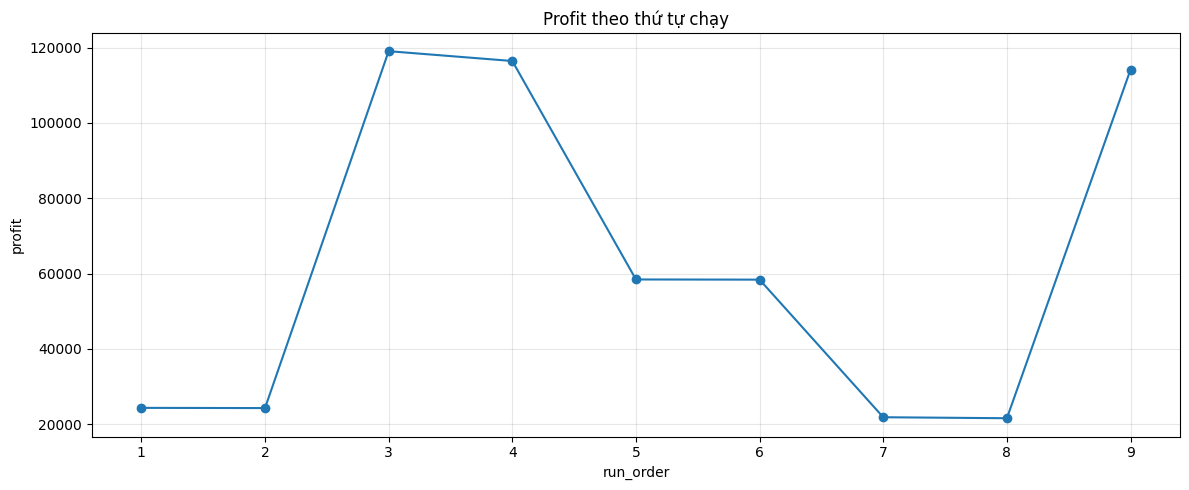

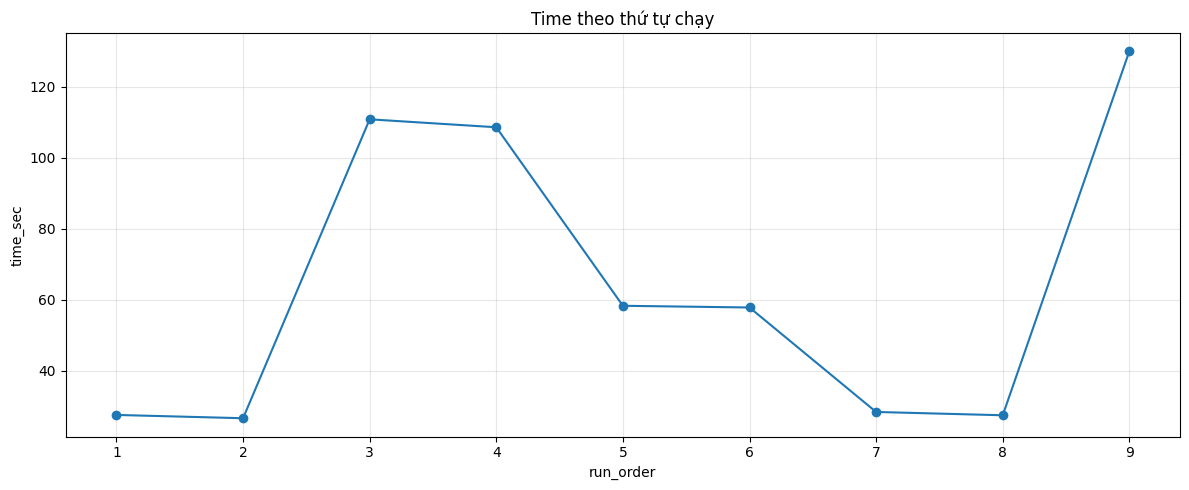

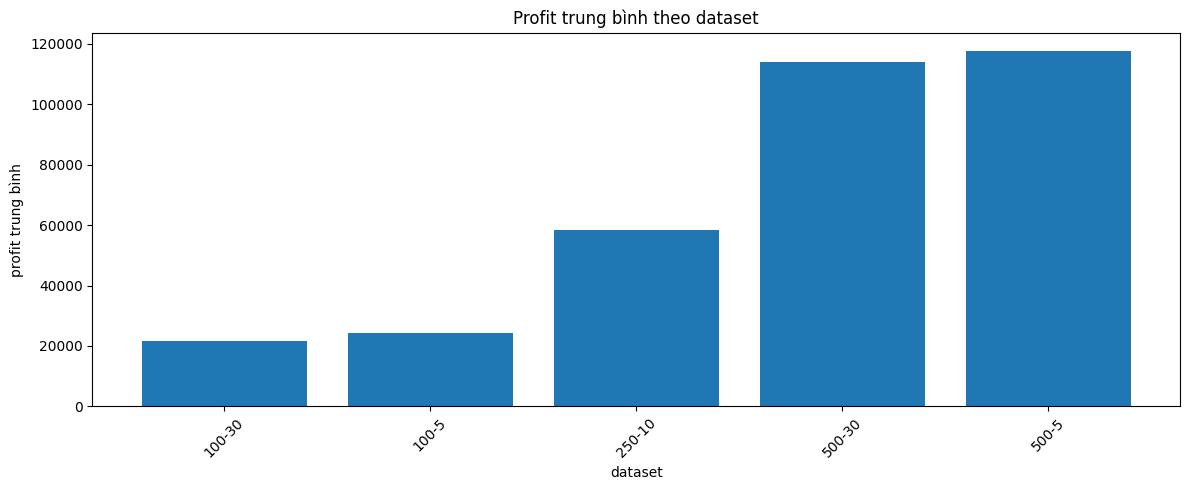

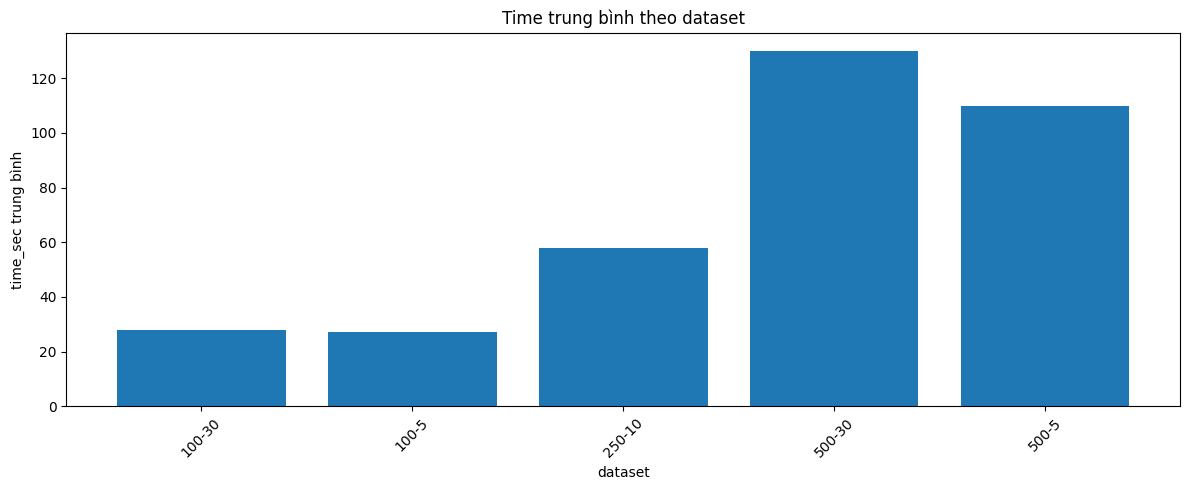

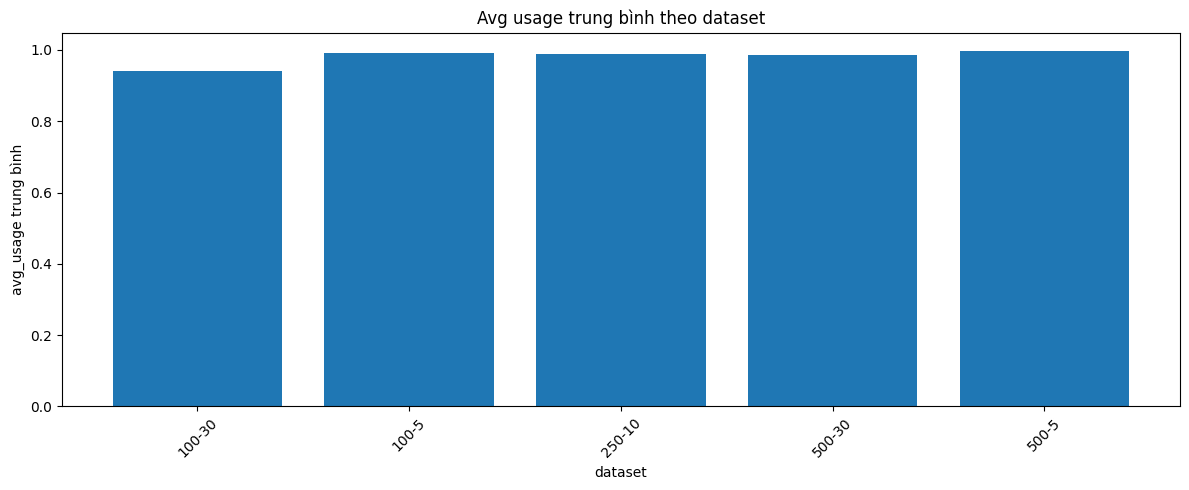

In [13]:
if results_df.empty:
    print('Không có dữ liệu để vẽ biểu đồ.')
else:
    run_order = np.arange(1, len(results_df) + 1)

    plt.figure(figsize=(12, 5))
    plt.plot(run_order, results_df['profit'], marker='o')
    plt.xlabel('run_order')
    plt.ylabel('profit')
    plt.title('Profit theo thứ tự chạy')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(run_order, results_df['time_sec'], marker='o')
    plt.xlabel('run_order')
    plt.ylabel('time_sec')
    plt.title('Time theo thứ tự chạy')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    avg_profit = results_df.groupby('dataset', as_index=False)['profit'].mean()
    plt.figure(figsize=(12, 5))
    plt.bar(avg_profit['dataset'], avg_profit['profit'])
    plt.xlabel('dataset')
    plt.ylabel('profit trung bình')
    plt.title('Profit trung bình theo dataset')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    avg_time = results_df.groupby('dataset', as_index=False)['time_sec'].mean()
    plt.figure(figsize=(12, 5))
    plt.bar(avg_time['dataset'], avg_time['time_sec'])
    plt.xlabel('dataset')
    plt.ylabel('time_sec trung bình')
    plt.title('Time trung bình theo dataset')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    avg_usage = results_df.groupby('dataset', as_index=False)['avg_usage'].mean()
    plt.figure(figsize=(12, 5))
    plt.bar(avg_usage['dataset'], avg_usage['avg_usage'])
    plt.xlabel('dataset')
    plt.ylabel('avg_usage trung bình')
    plt.title('Avg usage trung bình theo dataset')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
